<a href="https://www.kaggle.com/code/ariffinsamsu/notebook2fec4d9996?scriptVersionId=331880578" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# Cell 1 — Setup (run this once at the top of every notebook)
import sqlite3
import pandas as pd

# Connect to the Olist SQLite database
conn = sqlite3.connect('/kaggle/input/datasets/terencicp/e-commerce-dataset-by-olist-as-an-sqlite-database/olist.sqlite')

print("Connected successfully!")
print("Tables available:")
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", conn)
print(tables)

Connected successfully!
Tables available:
                                 name
0                           customers
1                         geolocation
2                        leads_closed
3                     leads_qualified
4                         order_items
5                      order_payments
6                       order_reviews
7                              orders
8   product_category_name_translation
9                            products
10                            sellers


In [2]:
# ── 00_exploration.sql ──────────────────────────────────────────────

# Row counts across all tables
query = """
SELECT 
                         'customers'       AS table_name, 
                         COUNT(*) AS row_count FROM customers
UNION ALL
SELECT 'orders',         COUNT(*) FROM orders
UNION ALL
SELECT 'order_items',    COUNT(*) FROM order_items
UNION ALL
SELECT 'order_payments', COUNT(*) FROM order_payments
UNION ALL
SELECT 'order_reviews',  COUNT(*) FROM order_reviews
UNION ALL
SELECT 'products',       COUNT(*) FROM products
UNION ALL
SELECT 'sellers',        COUNT(*) FROM sellers;
"""
pd.read_sql(query, conn)

,table_name,row_count
0,customers,99441
1,orders,99441
2,order_items,112650
3,order_payments,103886
4,order_reviews,99224
5,products,32951
6,sellers,3095


In [3]:
# Date range and total order count
query = """
SELECT
    MIN(order_purchase_timestamp) AS earliest_order,
    MAX(order_purchase_timestamp) AS latest_order,
    COUNT(DISTINCT order_id)      AS total_orders
FROM orders;
"""
pd.read_sql(query, conn)

,earliest_order,latest_order,total_orders
0,2016-09-04 21:15:19,2018-10-17 17:30:18,99441


In [4]:
# Order status breakdown
query = """
SELECT
    order_status,
    COUNT(*)                                          AS count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct
FROM orders
GROUP BY order_status
ORDER BY count DESC;
"""
pd.read_sql(query, conn)

,order_status,count,pct
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


In [5]:
# ── 01_monthly_revenue.sql ──────────────────────────────────────────

query = """
SELECT
    STRFTIME('%Y-%m', o.order_purchase_timestamp)  AS order_month,
    COUNT(DISTINCT o.order_id)                     AS total_orders,
    ROUND(SUM(oi.price), 2)                        AS gross_revenue,
    ROUND(SUM(oi.freight_value), 2)                AS total_freight,
    ROUND(SUM(oi.price + oi.freight_value), 2)     AS total_gmv,
    ROUND(AVG(oi.price), 2)                        AS avg_order_value
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
  AND o.order_purchase_timestamp < '2018-09-01'
GROUP BY order_month
ORDER BY order_month;
"""
df_revenue = pd.read_sql(query, conn)
df_revenue

,order_month,total_orders,gross_revenue,total_freight,total_gmv,avg_order_value
0,2016-09,1,134.97,8.49,143.46,44.99
1,2016-10,265,40325.11,6165.55,46490.66,128.83
2,2016-12,1,10.90,8.72,19.62,10.90
3,2017-01,750,111798.36,15684.01,127482.37,122.45
4,2017-02,1653,234223.40,37015.92,271239.32,126.06
5,2017-03,2546,359198.85,55132.10,414330.95,123.99
6,2017-04,2303,340669.68,50142.72,390812.40,132.61
7,2017-05,3546,489338.25,77513.15,566851.40,122.21
8,2017-06,3135,421923.37,68127.00,490050.37,120.93
9,2017-07,3872,481604.52,84694.56,566299.08,109.06


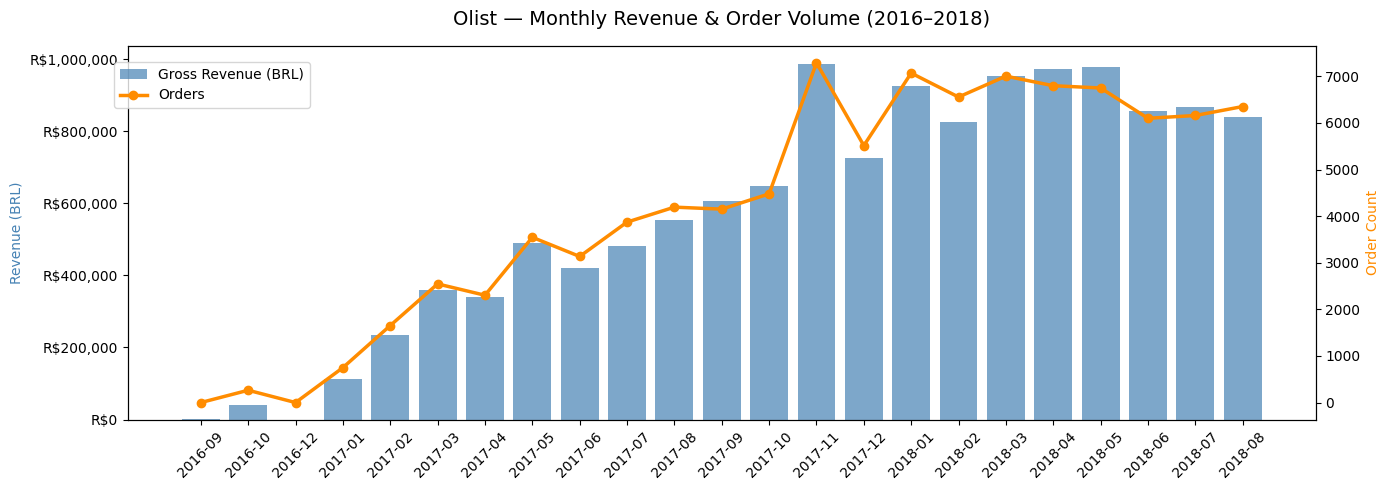

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(df_revenue['order_month'], df_revenue['gross_revenue'],
        color='steelblue', alpha=0.7, label='Gross Revenue (BRL)')
ax1.set_ylabel('Revenue (BRL)', color='steelblue')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(df_revenue['order_month'], df_revenue['total_orders'],
         color='darkorange', linewidth=2.5, marker='o', label='Orders')
ax2.set_ylabel('Order Count', color='darkorange')

ax1.set_title('Olist — Monthly Revenue & Order Volume (2016–2018)', fontsize=14, pad=15)
fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.88))
plt.tight_layout()
# plt.savefig('results/01_monthly_revenue.png', dpi=150, bbox_inches='tight') -> add this step to save the figure in directory
plt.show()


#Observations: 
#   1)Overall monthly revenue and orders of the e-commerce store increase almost gradually from Sept 2016 to early-2018 which then stabilize for the rest of 2018.
#   2)Significant spike on Nov 2017 was probably cause by surge of order for Black Friday as almost 80% of the orders are fulfilled before Black Friday. 

In [7]:
query = """
SELECT
    STRFTIME('%Y-%m-%d', o.order_purchase_timestamp)  AS order_day,
    COUNT(DISTINCT o.order_id)                     AS total_orders,
    ROUND(SUM(oi.price), 2)                        AS gross_revenue,
    ROUND(SUM(oi.freight_value), 2)                AS total_freight,
    ROUND(SUM(oi.price + oi.freight_value), 2)     AS total_gmv,
    ROUND(AVG(oi.price), 2)                        AS avg_order_value
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
  AND o.order_purchase_timestamp >= '2017-11-01' AND o.order_purchase_timestamp < '2017-11-30'
GROUP BY order_day
ORDER BY order_day;
"""
df_nov = pd.read_sql(query, conn)
df_nov

,order_day,total_orders,gross_revenue,total_freight,total_gmv,avg_order_value
0,2017-11-01,108,19363.71,2665.46,22029.17,153.68
1,2017-11-02,117,21074.93,2750.70,23825.63,149.47
2,2017-11-03,138,22844.05,3192.10,26036.15,135.17
3,2017-11-04,106,19033.27,3040.95,22074.22,147.54
4,2017-11-05,137,16323.76,3491.96,19815.72,103.31
5,2017-11-06,182,27673.15,4430.78,32103.93,137.68
6,2017-11-07,154,19711.71,3684.38,23396.09,113.29
7,2017-11-08,169,18594.64,3864.04,22458.68,95.85
8,2017-11-09,182,24307.55,3737.58,28045.13,112.53
9,2017-11-10,159,18789.56,3220.90,22010.46,102.68


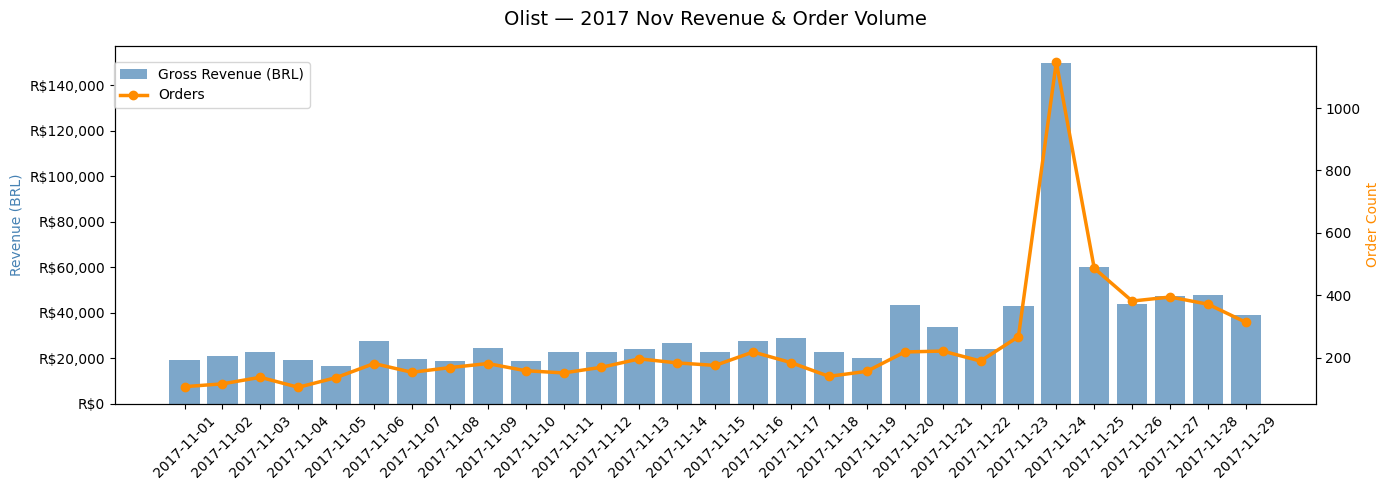

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(df_nov['order_day'], df_nov['gross_revenue'],
        color='steelblue', alpha=0.7, label='Gross Revenue (BRL)')
ax1.set_ylabel('Revenue (BRL)', color='steelblue')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(df_nov['order_day'], df_nov['total_orders'],
         color='darkorange', linewidth=2.5, marker='o', label='Orders')
ax2.set_ylabel('Order Count', color='darkorange')

ax1.set_title('Olist — 2017 Nov Revenue & Order Volume', fontsize=14, pad=15)
fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.88))
plt.tight_layout()
# plt.savefig('results/01_monthly_revenue.png', dpi=150, bbox_inches='tight') -> add this step to save the figure in directory
plt.show()

#Based on the graph below, the surge on Nov 2017 was highly influenced by order fulfilled on 

In [9]:
#Nov 2017 spike cause analysis

query ="""
WITH 
aggregated AS (
    SELECT
        STRFTIME('%Y-%m-%d', order_purchase_timestamp)  AS order_day,
        COUNT(order_id) AS total_orders
    FROM orders
    WHERE strftime('%Y-%m', order_purchase_timestamp) = '2017-11'
    GROUP BY order_day
)
SELECT
    order_day,
    total_orders,
    ROUND(
        100.0 * total_orders / SUM(total_orders) OVER (),
        2
    ) AS percentage
FROM aggregated
ORDER BY total_orders DESC
 ;
"""
df_nov = pd.read_sql(query, conn)
df_nov

,order_day,total_orders,percentage
0,2017-11-24,1176,15.59
1,2017-11-25,499,6.61
2,2017-11-27,403,5.34
3,2017-11-26,391,5.18
4,2017-11-28,380,5.04
5,2017-11-29,323,4.28
6,2017-11-23,283,3.75
7,2017-11-30,267,3.54
8,2017-11-20,230,3.05
9,2017-11-21,228,3.02


In [10]:
query ="""
WITH categorized_orders AS (
    SELECT
        CASE
            WHEN DATE(order_purchase_timestamp) < '2017-11-24' THEN 'Before Black Friday'
            WHEN DATE(order_purchase_timestamp) = '2017-11-24' THEN 'Black Friday'
            ELSE 'After Black Friday'
        END AS period,
        order_id
    FROM orders
    WHERE strftime('%Y-%m', order_purchase_timestamp) = '2017-11'
),
aggregated AS (
    SELECT
        period,
        COUNT(order_id) AS total_orders
    FROM categorized_orders
    GROUP BY period
)
SELECT
    period,
    total_orders,
    ROUND(
        100.0 * total_orders / SUM(total_orders) OVER (),
        2
    ) AS percentage
FROM aggregated;
"""

pd.read_sql(query, conn)

,period,total_orders,percentage
0,After Black Friday,2263,30.00
1,Before Black Friday,4105,54.41
2,Black Friday,1176,15.59


In [11]:
# ── 02_category_performance.sql ─────────────────────────────────────

query = """
SELECT
    COALESCE(p.product_category_name, 'uncategorised') AS category,
    COUNT(DISTINCT o.order_id)            AS order_count,
    COUNT(oi.order_item_id)               AS items_sold,
    ROUND(SUM(oi.price), 2)              AS revenue,
    ROUND(AVG(oi.price), 2)              AS avg_item_price,
    ROUND(AVG(oi.freight_value), 2)      AS avg_freight,
    ROUND(SUM(oi.price) * 100.0 /
          SUM(SUM(oi.price)) OVER(), 2)  AS revenue_share_pct
FROM orders o
JOIN order_items oi ON o.order_id  = oi.order_id
JOIN products    p  ON oi.product_id = p.product_id
WHERE o.order_status = 'delivered'
GROUP BY category
ORDER BY revenue DESC
LIMIT 15;
"""
df_cat = pd.read_sql(query, conn)
df_cat

,category,order_count,items_sold,revenue,avg_item_price,avg_freight,revenue_share_pct
0,beleza_saude,8647,9465,1233131.72,130.28,18.91,9.33
1,relogios_presentes,5495,5859,1166176.98,199.04,16.75,8.82
2,cama_mesa_banho,9272,10953,1023434.76,93.44,18.42,7.74
3,esporte_lazer,7530,8431,954852.55,113.25,19.38,7.22
4,informatica_acessorios,6530,7644,888724.61,116.26,18.84,6.72
5,moveis_decoracao,6307,8160,711927.69,87.25,20.64,5.38
6,utilidades_domesticas,5743,6795,615628.69,90.60,21.01,4.66
7,cool_stuff,3559,3718,610204.10,164.12,21.91,4.62
8,automotivo,3810,4140,578966.65,139.85,21.86,4.38
9,brinquedos,3804,4030,471286.48,116.94,18.80,3.56


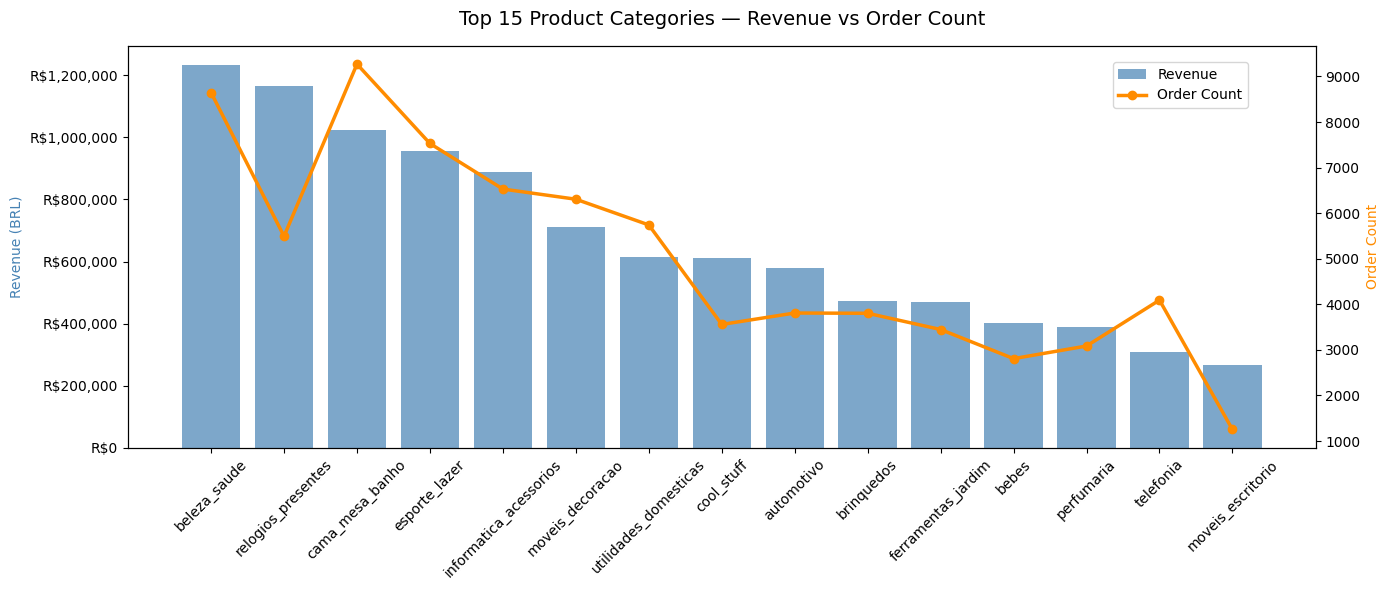

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- BAR CHART: Revenue ---
ax1.bar(
    df_cat['category'],
    df_cat['revenue'],
    color='steelblue',
    alpha=0.7,
    label='Revenue'
)

ax1.set_ylabel('Revenue (BRL)', color='steelblue')
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}')
)
ax1.tick_params(axis='x', rotation=45)

# --- LINE CHART: Order Count ---
ax2 = ax1.twinx()
ax2.plot(
    df_cat['category'],
    df_cat['order_count'],
    color='darkorange',
    marker='o',
    linewidth=2.5,
    label='Order Count'
)

ax2.set_ylabel('Order Count', color='darkorange')

# --- Title ---
ax1.set_title('Top 15 Product Categories — Revenue vs Order Count', fontsize=14, pad=15)

# --- Combined legend ---
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))

plt.tight_layout()
plt.show()

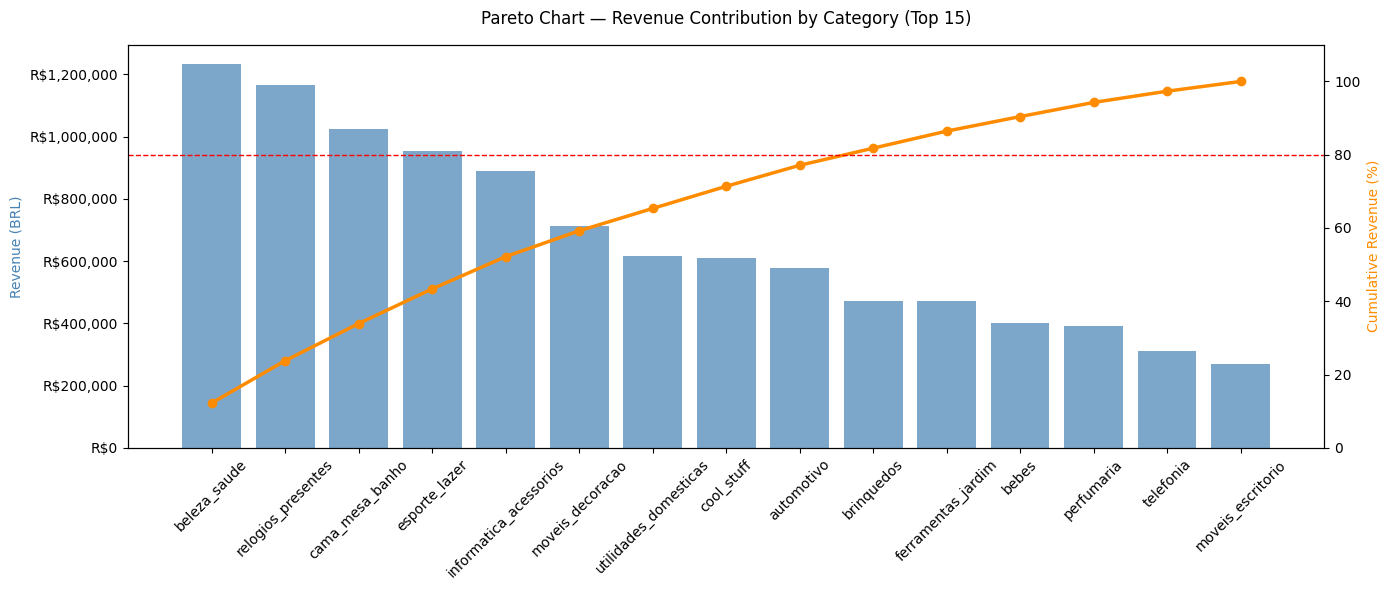

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker

# Sort by revenue descending
df_pareto = df_cat.sort_values('revenue', ascending=False).reset_index(drop=True)

# Compute cumulative percentage
df_pareto['cum_revenue_pct'] = df_pareto['revenue'].cumsum() / df_pareto['revenue'].sum() * 100

fig, ax1 = plt.subplots(figsize=(14, 6))

# BAR: Revenue
ax1.bar(df_pareto['category'], df_pareto['revenue'], color='steelblue', alpha=0.7)
ax1.set_ylabel('Revenue (BRL)', color='steelblue')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

# LINE: Cumulative %
ax2 = ax1.twinx()
ax2.plot(df_pareto['category'], df_pareto['cum_revenue_pct'],
         color='darkorange', marker='o', linewidth=2.5)

ax2.axhline(80, color='red', linestyle='--', linewidth=1)  # 80% reference line
ax2.set_ylabel('Cumulative Revenue (%)', color='darkorange')
ax2.set_ylim(0, 110)

plt.title('Pareto Chart — Revenue Contribution by Category (Top 15)', pad=15)
plt.tight_layout()
plt.show()

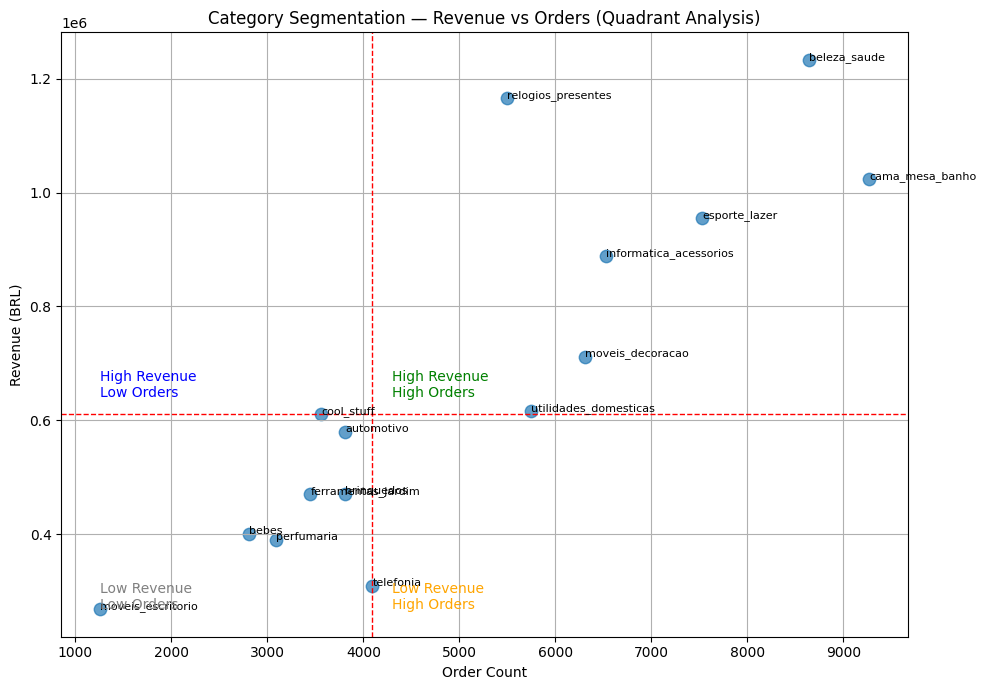

In [14]:
import matplotlib.pyplot as plt

# --- Calculate thresholds (median split for quadrants) ---
x_median = df_cat['order_count'].median()
y_median = df_cat['revenue'].median()

plt.figure(figsize=(10, 7))

# --- Scatter plot ---
plt.scatter(
    df_cat['order_count'],
    df_cat['revenue'],
    s=80,
    alpha=0.7
)

# --- Add category labels ---
for i, row in df_cat.iterrows():
    plt.text(
        row['order_count'],
        row['revenue'],
        row['category'],
        fontsize=8
    )

# --- Quadrant lines ---
plt.axvline(x=x_median, color='red', linestyle='--', linewidth=1)
plt.axhline(y=y_median, color='red', linestyle='--', linewidth=1)

# --- Quadrant annotations ---
plt.text(x_median*1.05, y_median*1.05, 'High Revenue\nHigh Orders', fontsize=10, color='green')
plt.text(df_cat['order_count'].min(), y_median*1.05, 'High Revenue\nLow Orders', fontsize=10, color='blue')
plt.text(x_median*1.05, df_cat['revenue'].min(), 'Low Revenue\nHigh Orders', fontsize=10, color='orange')
plt.text(df_cat['order_count'].min(), df_cat['revenue'].min(), 'Low Revenue\nLow Orders', fontsize=10, color='gray')

# --- Labels & title ---
plt.xlabel('Order Count')
plt.ylabel('Revenue (BRL)')
plt.title('Category Segmentation — Revenue vs Orders (Quadrant Analysis)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
# ── 03_delivery_sla.sql ─────────────────────────────────────────────

query = """
SELECT
    CASE
        WHEN JULIANDAY(o.order_delivered_customer_date) -
             JULIANDAY(o.order_estimated_delivery_date) <= 0
             THEN 'On Time'
        WHEN JULIANDAY(o.order_delivered_customer_date) -
             JULIANDAY(o.order_estimated_delivery_date) BETWEEN 0 AND 7
             THEN '1–7 Days Late'
        WHEN JULIANDAY(o.order_delivered_customer_date) -
             JULIANDAY(o.order_estimated_delivery_date) BETWEEN 7 AND 14
             THEN '8–14 Days Late'
        ELSE '14+ Days Late'
    END AS delivery_band,
    COUNT(*)                                                AS order_count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2)     AS pct_of_total,
    ROUND(AVG(
        JULIANDAY(o.order_delivered_customer_date) -
        JULIANDAY(o.order_estimated_delivery_date)
    ), 1)                                                   AS avg_days_deviation
FROM orders o
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND o.order_estimated_delivery_date IS NOT NULL
GROUP BY delivery_band
ORDER BY order_count DESC;
"""
df_sla = pd.read_sql(query, conn)
df_sla

,delivery_band,order_count,pct_of_total,avg_days_deviation
0,On Time,88644,91.89,-13.0
1,1–7 Days Late,4481,4.64,2.9
2,8–14 Days Late,1790,1.86,10.0
3,14+ Days Late,1555,1.61,28.2


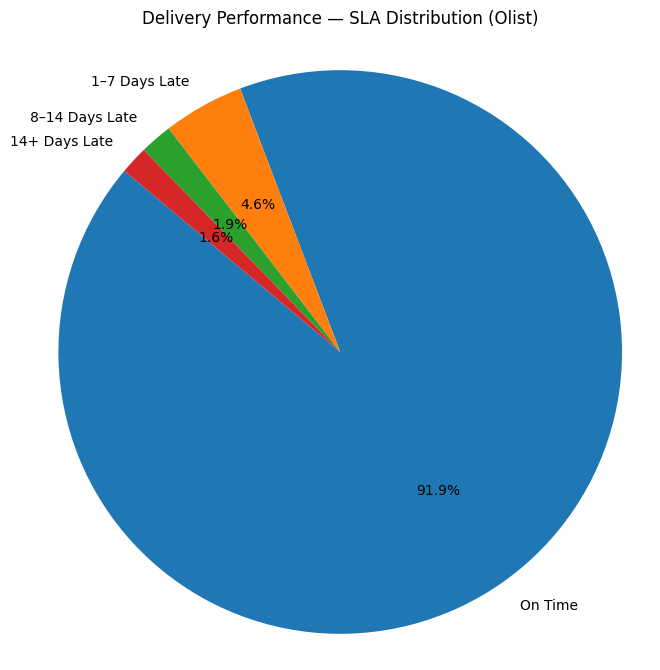

In [16]:
import matplotlib.pyplot as plt

# assuming result is stored like this
df_sla = pd.read_sql(query, conn)

# Ensure correct order (optional but nicer for storytelling)
df_sla = df_sla.sort_values('pct_of_total', ascending=False)

plt.figure(figsize=(8, 8))

plt.pie(
    df_sla['pct_of_total'],
    labels=df_sla['delivery_band'],
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Delivery Performance — SLA Distribution (Olist)', pad=15)
plt.axis('equal')  # ensures circle shape
plt.show()

In [17]:
query="""

SELECT
    CASE
        WHEN JULIANDAY(o.order_delivered_customer_date) -
             JULIANDAY(o.order_estimated_delivery_date) <= 0
             THEN 'On Time'
        WHEN JULIANDAY(o.order_delivered_customer_date) -
             JULIANDAY(o.order_estimated_delivery_date) BETWEEN 0 AND 7
             THEN '1–7 Days Late'
        WHEN JULIANDAY(o.order_delivered_customer_date) -
             JULIANDAY(o.order_estimated_delivery_date) BETWEEN 7 AND 14
             THEN '8–14 Days Late'
        ELSE '14+ Days Late'
    END AS delivery_band,

    COUNT(DISTINCT o.order_id) AS order_count,

    ROUND(SUM(p.payment_value), 2) AS revenue,

    ROUND(SUM(p.payment_value) * 100.0 / SUM(SUM(p.payment_value)) OVER(), 2) AS revenue_share_pct,

    ROUND(AVG(
        JULIANDAY(o.order_delivered_customer_date) -
        JULIANDAY(o.order_estimated_delivery_date)
    ), 1) AS avg_days_deviation

FROM orders o
    JOIN order_payments p
    ON o.order_id = p.order_id

WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND o.order_estimated_delivery_date IS NOT NULL

GROUP BY delivery_band
ORDER BY order_count DESC;
"""

df_sla_rev = pd.read_sql(query, conn)
df_sla_rev

,delivery_band,order_count,revenue,revenue_share_pct,avg_days_deviation
0,On Time,88644,14069436.06,91.24,-13.0
1,1–7 Days Late,4481,744135.01,4.83,2.9
2,8–14 Days Late,1790,319172.03,2.07,10.0
3,14+ Days Late,1554,288339.75,1.87,28.2


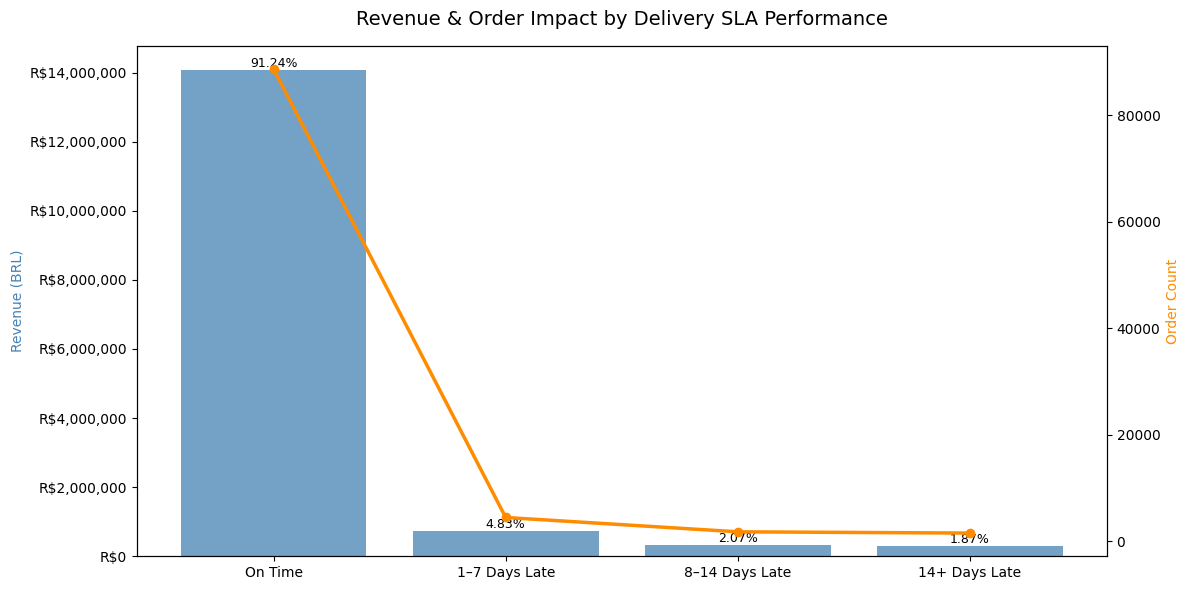

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df_sla_rev = pd.read_sql_query(query, conn)

# Keep consistent order (important for storytelling)
order_map = {
    'On Time': 0,
    '1–7 Days Late': 1,
    '8–14 Days Late': 2,
    '14+ Days Late': 3
}

df_sla_rev['sort_key'] = df_sla_rev['delivery_band'].map(order_map)
df_sla_rev = df_sla_rev.sort_values('sort_key')

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Revenue (Bar) ---
ax1.bar(
    df_sla_rev['delivery_band'],
    df_sla_rev['revenue'],
    color='steelblue',
    alpha=0.75
)

ax1.set_ylabel('Revenue (BRL)', color='steelblue')
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}')
)

# --- Revenue share labels ---
for i, v in enumerate(df_sla_rev['revenue_share_pct']):
    ax1.text(i, df_sla_rev['revenue'].iloc[i],
             f"{v}%", ha='center', va='bottom', fontsize=9)

# --- Orders (Line) ---
ax2 = ax1.twinx()

ax2.plot(
    df_sla_rev['delivery_band'],
    df_sla_rev['order_count'],
    color='darkorange',
    marker='o',
    linewidth=2.5
)

ax2.set_ylabel('Order Count', color='darkorange')

# --- Title ---
plt.title('Revenue & Order Impact by Delivery SLA Performance', fontsize=14, pad=15)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [19]:
# ── 04_seller_ranking.sql ───────────────────────────────────────────

query = """
WITH seller_stats AS (
    SELECT
        s.seller_id,
        s.seller_state,
        COUNT(DISTINCT o.order_id)              AS orders_completed,
        ROUND(SUM(oi.price), 2)                 AS total_revenue,
        ROUND(AVG(r.review_score), 2)           AS avg_rating,
        COUNT(DISTINCT p.product_category_name) AS category_diversity
    FROM sellers      s
    JOIN order_items  oi ON s.seller_id   = oi.seller_id
    JOIN orders       o  ON oi.order_id   = o.order_id
    JOIN order_reviews r ON o.order_id    = r.order_id
    JOIN products     p  ON oi.product_id = p.product_id
    WHERE o.order_status = 'delivered'
    GROUP BY s.seller_id, s.seller_state
    HAVING orders_completed >= 10
),
seller_ranked AS (
    SELECT *,
        RANK() OVER (ORDER BY total_revenue DESC)   AS revenue_rank,
        RANK() OVER (ORDER BY avg_rating DESC)      AS rating_rank,
        NTILE(4) OVER (ORDER BY total_revenue DESC) AS revenue_quartile
    FROM seller_stats
)
SELECT
    seller_id,
    seller_state,
    orders_completed,
    total_revenue,
    avg_rating,
    category_diversity,
    revenue_rank,
    rating_rank,
    CASE revenue_quartile
        WHEN 1 THEN 'Q1 — Top 25%'
        WHEN 2 THEN 'Q2 — Upper Mid'
        WHEN 3 THEN 'Q3 — Lower Mid'
        WHEN 4 THEN 'Q4 — Bottom 25%'
    END AS performance_tier
FROM seller_ranked
ORDER BY total_revenue DESC
LIMIT 10;
"""
pd.read_sql(query, conn)

,seller_id,seller_state,orders_completed,total_revenue,avg_rating,category_diversity,revenue_rank,rating_rank,performance_tier
0,4869f7a5dfa277a7dca6462dcf3b52b2,SP,1116,225586.34,4.14,10,1,676,Q1 — Top 25%
1,53243585a1d6dc2643021fd1853d8905,BA,346,215904.44,4.13,2,2,685,Q1 — Top 25%
2,4a3ca9315b744ce9f8e9374361493884,SP,1753,197225.32,3.83,7,3,1001,Q1 — Top 25%
3,fa1c13f2614d7b5c4749cbc52fecda94,SP,574,189649.54,4.37,5,4,334,Q1 — Top 25%
4,7c67e1448b00f6e969d365cea6b010ab,SP,967,186664.01,3.35,6,5,1181,Q1 — Top 25%
5,7e93a43ef30c4f03f38b393420bc753a,SP,318,165751.50,4.36,7,6,343,Q1 — Top 25%
6,da8622b14eb17ae2831f4ac5b9dab84a,SP,1305,161574.27,4.08,4,7,750,Q1 — Top 25%
7,7a67c85e85bb2ce8582c35f2203ad736,SP,1137,139188.73,4.27,2,8,488,Q1 — Top 25%
8,1025f0e2d44d7041d6cf58b6550e0bfa,SP,902,138691.40,3.87,4,9,980,Q1 — Top 25%
9,955fee9216a65b617aa5c0531780ce60,SP,1253,130823.82,4.09,22,10,738,Q1 — Top 25%


In [20]:
query ="""

WITH state_stats AS (
    SELECT
        s.seller_state,

        COUNT(DISTINCT s.seller_id)   AS num_sellers,
        COUNT(DISTINCT o.order_id)    AS total_orders,
        ROUND(SUM(oi.price), 2)       AS total_revenue,
        ROUND(AVG(r.review_score), 2) AS avg_rating

    FROM sellers s
    JOIN order_items oi
        ON s.seller_id = oi.seller_id
    JOIN orders o
        ON oi.order_id = o.order_id
    JOIN order_reviews r
        ON o.order_id = r.order_id

    WHERE o.order_status = 'delivered'

    GROUP BY s.seller_state
)

SELECT
    seller_state,
    num_sellers,
    total_orders,

    -- % of total orders
    ROUND(
        total_orders * 100.0 / SUM(total_orders) OVER(),
        2
    ) AS pct_orders,
    
    total_revenue,

    -- % of total revenue
    ROUND(
        total_revenue * 100.0 / SUM(total_revenue) OVER(),
        2
    ) AS pct_revenue,
    
    avg_rating




FROM state_stats
ORDER BY total_revenue DESC
LIMIT 10;
"""
pd.read_sql(query, conn)

,seller_state,num_sellers,total_orders,pct_orders,total_revenue,pct_revenue,avg_rating
0,SP,1767,68173,70.76,8478918.77,64.39,4.05
1,PR,333,7461,7.74,1226435.57,9.31,4.13
2,MG,235,7683,7.97,971995.71,7.38,4.16
3,RJ,163,4197,4.36,816821.48,6.20,4.17
4,SC,184,3584,3.72,612357.18,4.65,4.13
5,RS,125,1945,2.02,373262.62,2.83,4.25
6,BA,18,548,0.57,276010.51,2.10,4.16
7,DF,30,807,0.84,94842.19,0.72,4.07
8,PE,9,401,0.42,89226.25,0.68,4.15
9,GO,39,450,0.47,64820.50,0.49,4.31


In [21]:
 # ── 05_rfm_segmentation.sql ─────────────────────────────────────────

query = """
WITH rfm_base AS (
    SELECT
        c.customer_unique_id,
        CAST(
            JULIANDAY('2018-09-01') -
            JULIANDAY(MAX(o.order_purchase_timestamp))
        AS INTEGER)                  AS recency_days,
        COUNT(DISTINCT o.order_id)   AS frequency,
        ROUND(SUM(oi.price), 2)      AS monetary
    FROM customers   c
    JOIN orders      o  ON c.customer_id  = o.customer_id
    JOIN order_items oi ON o.order_id     = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),
rfm_scored AS (
    SELECT *,
        NTILE(5) OVER (ORDER BY recency_days ASC)   AS r_score,
        NTILE(5) OVER (ORDER BY frequency DESC)     AS f_score,
        NTILE(5) OVER (ORDER BY monetary DESC)      AS m_score
    FROM rfm_base
),
rfm_segmented AS (
    SELECT *,
        (r_score + f_score + m_score) AS rfm_total,
        CASE
            WHEN (r_score + f_score + m_score) >= 13  THEN 'Champions'
            WHEN (r_score + f_score + m_score) >= 10  THEN 'Loyal Customers'
            WHEN r_score >= 4 AND f_score <= 2        THEN 'New Customers'
            WHEN r_score <= 2 AND f_score >= 3        THEN 'At Risk'
            WHEN r_score <= 2 AND m_score >= 3        THEN 'Cant Lose Them'
            ELSE 'Needs Attention'
        END AS segment
    FROM rfm_scored
)
SELECT
    segment,
    COUNT(*)                          AS customer_count,
    ROUND(AVG(recency_days), 0)       AS avg_recency_days,
    ROUND(AVG(frequency), 1)          AS avg_orders,
    ROUND(AVG(monetary), 2)           AS avg_spend_brl,
    ROUND(SUM(monetary), 2)           AS total_segment_revenue
FROM rfm_segmented
GROUP BY segment
ORDER BY total_segment_revenue DESC;
"""
df_rfm = pd.read_sql(query, conn)
df_rfm

,segment,customer_count,avg_recency_days,avg_orders,avg_spend_brl,total_segment_revenue
0,Needs Attention,26556,149.0,1.1,240.58,6388773.96
1,New Customers,14390,395.0,1.1,278.87,4012970.58
2,Loyal Customers,25979,239.0,1.0,55.79,1449284.96
3,At Risk,11054,77.0,1.0,77.47,856299.86
4,Champions,15106,373.0,1.0,32.70,493893.70
5,Cant Lose Them,273,90.0,2.0,74.27,20275.05


In [22]:
# ── 06_bonus_mom_growth.sql ─────────────────────────────────────────

query = """
WITH monthly AS (
    SELECT
        STRFTIME('%Y-%m', o.order_purchase_timestamp) AS order_month,
        ROUND(SUM(oi.price), 2)                        AS revenue,
        COUNT(DISTINCT o.order_id)                     AS orders
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_purchase_timestamp < '2018-09-01'
    GROUP BY order_month
)
SELECT
    order_month,
    revenue,
    orders,
    LAG(revenue) OVER (ORDER BY order_month)          AS prev_month_revenue,
    ROUND(
        (revenue - LAG(revenue) OVER (ORDER BY order_month))
        / LAG(revenue) OVER (ORDER BY order_month) * 100,
    1)                                                 AS mom_growth_pct,
    ROUND(
        SUM(revenue) OVER (ORDER BY order_month),
    2)                                                 AS cumulative_revenue
FROM monthly
ORDER BY order_month;
"""
pd.read_sql(query, conn)

,order_month,revenue,orders,prev_month_revenue,mom_growth_pct,cumulative_revenue
0,2016-09,134.97,1,NaN,NaN,134.97
1,2016-10,40325.11,265,134.97,29777.1,40460.08
2,2016-12,10.90,1,40325.11,-100.0,40470.98
3,2017-01,111798.36,750,10.90,1025573.0,152269.34
4,2017-02,234223.40,1653,111798.36,109.5,386492.74
5,2017-03,359198.85,2546,234223.40,53.4,745691.59
6,2017-04,340669.68,2303,359198.85,-5.2,1086361.27
7,2017-05,489338.25,3546,340669.68,43.6,1575699.52
8,2017-06,421923.37,3135,489338.25,-13.8,1997622.89
9,2017-07,481604.52,3872,421923.37,14.1,2479227.41


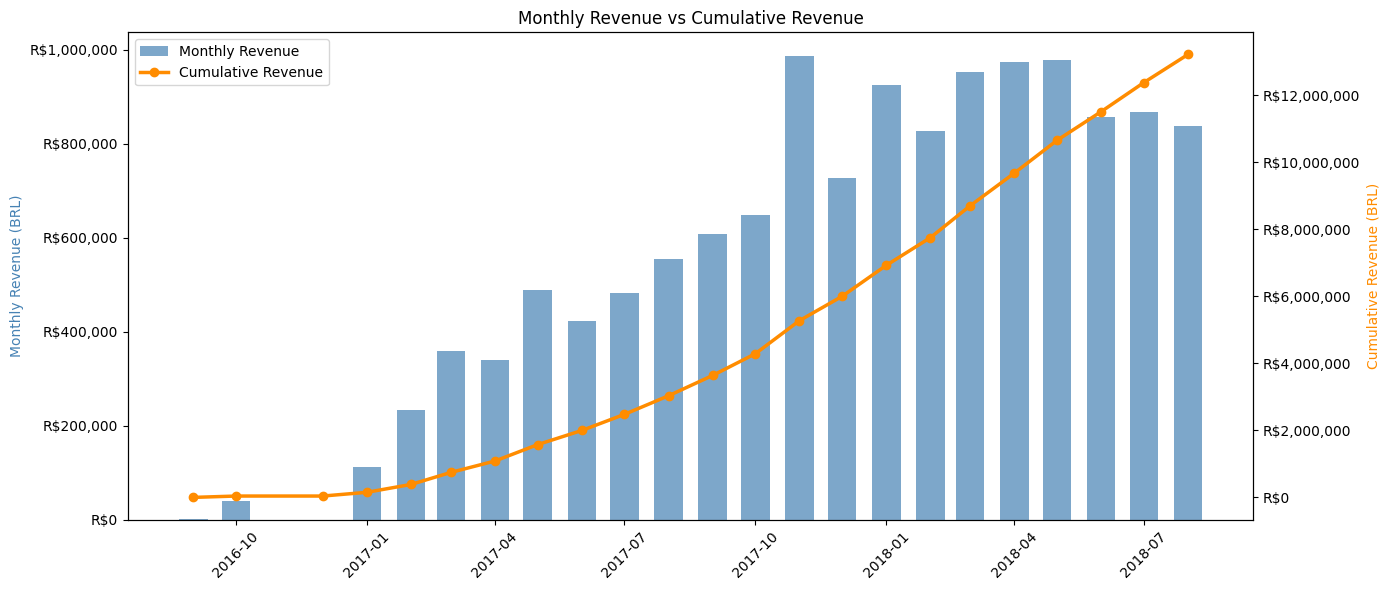

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Read SQL result
df_growth = pd.read_sql(query, conn)

# Convert month to datetime
df_growth['order_month'] = pd.to_datetime(df_growth['order_month'])

fig, ax1 = plt.subplots(figsize=(14,6))

# -----------------------------
# Bar chart: Monthly Revenue
# -----------------------------
ax1.bar(
    df_growth['order_month'],
    df_growth['revenue'],
    width=20,
    color='steelblue',
    alpha=0.7,
    label='Monthly Revenue'
)

ax1.set_ylabel('Monthly Revenue (BRL)', color='steelblue')
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}')
)

ax1.tick_params(axis='x', rotation=45)

# -----------------------------
# Line chart: Cumulative Revenue
# -----------------------------
ax2 = ax1.twinx()

ax2.plot(
    df_growth['order_month'],
    df_growth['cumulative_revenue'],
    color='darkorange',
    marker='o',
    linewidth=2.5,
    label='Cumulative Revenue'
)

ax2.set_ylabel('Cumulative Revenue (BRL)', color='darkorange')
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}')
)

# -----------------------------
# Combined Legend
# -----------------------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Monthly Revenue vs Cumulative Revenue')
plt.tight_layout()

# Save figure (optional)
# plt.savefig('results/06_monthly_vs_cumulative_revenue.png', dpi=150, bbox_inches='tight')

plt.show()